# Computing Saliency Attribution for Gender-Contrastive Translations

# Install inseq requirements

In [ ]:
!python --version

In [ ]:
pip install inseq

In [ ]:
pip install sacremoses

In [2]:
%%capture
# Run in Colab to install local packages
%pip install bitsandbytes accelerate transformers inseq

In [ ]:
!python -c "import inseq; print(inseq.get_version())"

In [4]:
import inseq
from inseq.data.aggregator import SubwordAggregator

# Open file

In [ ]:
pip install "numpy<2.1.0" "pandas==2.2.2"

In [ ]:
from google.colab import files

# Upload file
uploaded = files.upload()

In [ ]:
import pandas as pd

# Read the tab-separated text into a pandas DataFrame
df = pd.read_excel('source_data-and-contrastive_translations.xlsx')


# Access columns and save contents to a list
EN_source = df["EN_source"].tolist()
Opus_MT_ES = df["OPUS-MT_ES"].tolist()
Opus_MT_ES_contrastive = df["OPUS-MT_ES_contrastive"].tolist()
Opus_MT_DE = df["OPUS-MT_DE"].tolist()
Opus_MT_DE_contrastive = df["OPUS-MT_DE_contrastive"].tolist()


print(f"EN Source: {EN_source[1]}")
print(f"OPUS-MT ES Translation: {Opus_MT_ES[1]}")
print(f"OPUS-MT ES Contrastive Translation: {Opus_MT_ES_contrastive[1]}")
print(f"OPUS-MT DE Translation: {Opus_MT_DE[1]}")
print(f"OPUS-MT DE Contrastive Translation: {Opus_MT_DE_contrastive[1]}")

EN Source Satistics: print average length of EN source sentences and standard deviation.

In [ ]:
import numpy as np

#  Calculate lengths, filter out NaN and keep only valid strings
sentence_lengths = [len(sentence.split()) for sentence in EN_source if isinstance(sentence, str)]

# Calculate statistics
average_length = np.mean(sentence_lengths)
std_length = np.std(sentence_lengths, ddof=1)  # ddof=1 for sample std deviation

# Print results
print("=== SENTENCE LENGTH STATISTICS ===")
print(f"Average length: {average_length:.2f} words")
print(f"Standard deviation: {std_length:.2f} words")
print(f"Min length: {min(sentence_lengths)} words")
print(f"Max length: {max(sentence_lengths)} words")
print(f"Total sentences: {len(sentence_lengths)}")

# Perform the Contrastive Attribution

We use [inseq](https://github.com/inseq-team/inseq) to compute saliency attribution scores for gender contrastive translations.

Load the Attribution Model: We chose Helsinki's OPUS-MT en-de (same as used for the translations), and we focus on 'saliency'.

CHOOSE YOUR TARGET LANGUAGE FOR ANALYSIS FIRST

In [8]:
# For later analyis, saving files

target_language = "ES" # ---> Change to "DE" for German

In [9]:
# To load the model

src = "en"  # source language
trg = "es"  # target language --> Change to "DE" for German

In [ ]:
import inseq

attribution_model = inseq.load_model(f"Helsinki-NLP/opus-mt-{src}-{trg}", "saliency")

### Attribution Visualisation
The cell below visualises inseq's display of saliency attribution for source and target tokens for our given English source and German target sentence. For this project, we focus on the source attribution.

This cell is purely for visualisation purposes, not required for the rest of the notebook (analysis).

In [ ]:
# To visualise: not necessary for the rest of the notebook

# Tests just the first few sentences
for i in range(5):
  en = EN_source[i]
  orig = Opus_MT_ES[i]
  cont = Opus_MT_ES_contrastive[i]


  # Gets original tokens in format [(0, '</s>'), (1, 'deu_Latn'), (2, '▁Beispi'), (3, 'els'), (4, 'atz'), (5, '▁auf'), (6, '▁Eng'), (7, 'lis'), (8, 'ch'), (9, ','), (10, '▁um'), (11, '▁zu'), (12, '▁zeigen'), (13, ','), (14, '▁wes'), (15, 'halb'), (16, '▁dies'), (17, '▁ein'), (18, '▁Problem'), (19, '▁für'), (20, '▁den'), (21, '▁Program'), (22, 'mi'), (23, 'erer'), (24, '▁ist'), (25, '.'), (26, '</s>')]
  orig_tokens = list(enumerate(attribution_model.encode(orig, as_targets=True).input_tokens[0]))

  out = attribution_model.attribute(
      en,
      orig ,
      contrast_targets=cont,
      attribute_target=True,
      attributed_fn="contrast_prob_diff",
      step_scores=["contrast_prob_diff"],
      contrast_targets_alignments=[(i,i) for i in range(len(orig_tokens))],
  )

  out.show()

Attributing with saliency...:   5%|▍         | 1/21 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/inseq/utils/contrast_utils.py:155: UserWarning: Contrastive inputs do not match original inputs when using a contrastive attributed function.
By default we force the original inputs to be used (i.e. only the contrastive predicted target is different).
This is a requirement for gradient-based attribution method, as contrastive inputs don't participate in gradient computation.
For attribution methods with less stringent requirements, set --contrast_force_inputs to True to use the contrastive inputs for attribution instead.
  warnings.warn(
Attributing with saliency...: 100%|██████████| 21/21 [00:01<00:00, 10.76it/s]


,,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
,,▁Lo,▁que,▁nunca,▁deberías,▁hacer,▁en,▁un,▁avión,:,▁La → ▁El,▁asistente,▁de,▁vuelo,▁revela,▁secretos,▁de,▁la,▁aerolínea,.,</s>
0,▁What,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.027,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,▁you,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.032,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,▁should,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,▁never,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,▁do,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.008,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,▁on,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,▁a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,▁plane,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.026,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,:,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.036,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Attributing with saliency...: 100%|██████████| 34/34 [00:02<00:00, 15.02it/s]


,,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32
,,▁En,▁un,▁video,▁de,▁Instagram,▁publicado,▁el,▁mes,▁pasado,",",▁la → ▁el,▁música → ▁músico,"▁""",A,ll,▁To,o,▁Well,"""",▁puede,▁verse,▁colaborando,▁con,▁el,▁productor,▁Jack,▁Anton,off,▁en,▁el,▁piano,.,</s>
0,▁In,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.008,0.004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,▁an,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.008,0.008,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,▁Instagram,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028,0.019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,▁video,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011,0.012,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,▁posted,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.014,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,▁last,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011,0.007,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,▁month,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.012,0.013,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,",",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01,0.006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,▁the,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.023,0.023,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Attributing with saliency...: 100%|██████████| 28/28 [00:01<00:00, 15.31it/s]


,,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26
,,▁El,▁jueves,▁por,▁la,▁noche,",",▁finalmente,",",▁salió,▁a,▁la,▁cancha,▁contra,▁una → ▁un,▁oponente,▁entre,▁los,▁10,▁mejores,▁por,▁segunda,▁vez,▁de,▁su,▁vida,.,</s>
0,▁On,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,▁Thursday,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.014,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,▁evening,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.014,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,",",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,▁finally,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.012,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,",",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,▁she,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,▁stepped,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.027,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,▁out,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.012,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Attributing with saliency...: 100%|██████████| 66/66 [00:04<00:00, 13.80it/s]


,,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64
,,▁El → ▁La,▁social,ita,▁que,▁consiguió,▁que,▁una,▁con,desa,▁escribi,era,▁un,▁manual,▁de,▁50,▁páginas,▁sobre,▁cosas,▁como,▁lo,▁llena,▁que,▁tenía,▁que,▁estar,▁una,▁caja,▁de,▁tejidos,▁antes,▁de,▁ser,▁de,se,cha,da,▁-,▁la,▁mitad,▁-,▁nunca,▁no,tó,▁la,▁línea,▁de,▁producción,▁de,▁la,▁fábrica,▁de,▁niños,▁recién,▁nacidos,▁de,▁chicas,▁menores,▁de,▁edad,▁que,▁iban,▁y,▁venían,.,</s>
0,▁The,0.041,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,▁social,0.142,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ite,0.272,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,▁who,0.049,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,▁got,0.023,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,▁a,0.014,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,▁count,0.046,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,es,0.032,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,s,0.017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Attributing with saliency...: 100%|██████████| 21/21 [00:01<00:00, 15.39it/s]


,,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
,,▁Te,ra,pe,uta,▁de,▁masaje,▁Ken,s,ington,▁encarcelado → ▁encarcela,▁por → da,▁a → ▁por,gre → ▁a,dir → gre,▁sexualmente → dir,▁a → ▁sexualmente,▁clientes → ▁a,. → ▁clientes,</s> → .,</s>
0,▁Ken,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.016,0.009,0.024,0.01,0.013,0.006,0.005,0.006,0.006,0.003,0.0
1,s,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011,0.007,0.006,0.005,0.004,0.003,0.002,0.004,0.003,0.002,0.0
2,ington,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.092,0.013,0.027,0.017,0.013,0.008,0.01,0.009,0.009,0.005,0.0
3,▁massage,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.032,0.048,0.046,0.037,0.025,0.028,0.017,0.028,0.021,0.027,0.0
4,▁therapist,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028,0.103,0.045,0.043,0.038,0.027,0.025,0.031,0.03,0.036,0.0
5,▁jail,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.014,0.033,0.075,0.031,0.038,0.028,0.014,0.029,0.024,0.011,0.0
6,ed,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.005,0.01,0.016,0.008,0.009,0.007,0.003,0.009,0.005,0.003,0.0
7,▁for,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.005,0.007,0.042,0.017,0.014,0.018,0.004,0.019,0.01,0.005,0.0
8,▁sexually,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.01,0.016,0.072,0.085,0.055,0.069,0.021,0.122,0.049,0.023,0.0


## Methodologies for Approaches 1-5

In [ ]:
pip install spacy

In [ ]:
!python -m spacy download en_core_web_lg

In [12]:
import spacy
nlp = spacy.load("en_core_web_lg")

## Run this first. Function that writes all source words and attribution scores to an Excel for further analysis

In [13]:
def save_all_normalized_merged_source_attributions_for_first_arrow_word(out, sentence_index, target_words, sheet_name=None):
    """
    Prints the top merged source word attributions for the first target token containing '→',
    after normalizing source attributions for that target token so that they sum to 1.
    Subword tokens are merged into whole words before ranking and printing.
    Also prints the indices of the constituent source tokens.
    Removes the specific target word for this sentence based on sentence_index.
    """
    out_data = out.sequence_attributions[0]
    # Get source tokens and optionally their ids and original index
    source_tokens = [t.token if hasattr(t, 'token') else str(t) for t in out_data.source]
    target_tokens = [t.token if hasattr(t, 'token') else str(t) for t in out_data.target]

    print(f"\n--- SENTENCE {sentence_index + 1} ---")
    print(source_tokens)
    print(target_tokens)

    # Remove end of line character from source tokens
    if "</s>" in source_tokens:
        source_tokens.remove("</s>")

    # Handle alignment window (important for correct attribution indexing)
    attr_pos_start = getattr(out_data, "attr_pos_start", 0)
    attr_pos_end = getattr(out_data, "attr_pos_end", len(target_tokens))
    aligned_target_tokens = target_tokens[attr_pos_start:attr_pos_end]  # Only tokens with attributions

    # Prepare attribution matrix (handle possible 3D tensor)
    saliency_heatmap = out_data.source_attributions
    if hasattr(saliency_heatmap, "shape") and len(saliency_heatmap.shape) == 3:
        saliency_heatmap = saliency_heatmap.sum(dim=2)

    contrast_scores = out_data.step_scores["contrast_prob_diff"]

    # Find first target token containing "→" in the aligned window
    target_word_index = next((i for i, token in enumerate(aligned_target_tokens) if "→" in token), None)
    if target_word_index is None:
        print("No target token containing '→' found.")
        return

    tgt_token = aligned_target_tokens[target_word_index]
    contrast_val = float(contrast_scores[target_word_index])

    # Collect and normalize attribution scores for this target token (column in matrix)
    raw_scores = [
        float(saliency_heatmap[i][target_word_index].item() if hasattr(saliency_heatmap[i][target_word_index], "item") else saliency_heatmap[i][target_word_index])
        for i in range(len(source_tokens))
    ]
    score_sum = sum(raw_scores)
    normalized_scores = [s / score_sum if score_sum != 0 else 0.0 for s in raw_scores]

    # Merge subwords into words and sum their attribution scores
    merged_words = []
    current_word = ""
    current_score = 0.0
    current_indices = []
    current_pos = ""

    for idx, (token, score) in enumerate(zip(source_tokens, normalized_scores)):
        if token.startswith("▁") or token in [".", "</s>"]:  # Start of a new word or special
            if current_word:
                merged_words.append((current_word, current_score, current_indices, current_pos))
            # Start new word
            current_word = token.lstrip("▁")
            current_score = score
            current_indices = [idx]
        else:
            current_word += token
            current_score += score
            current_indices.append(idx)
    # Add last word
    if current_word:
        merged_words.append((current_word, current_score, current_indices, current_pos))


    # Get the specific target word for this sentence
    current_target_word = target_words.get(sentence_index, "").lower()
    print(f"Target word for sentence {sentence_index + 1}: '{current_target_word}'")

    # Create a new list excluding the specific target word for this sentence
    filtered_words = []

    # Extract individual words from compound target words
    all_target_words = set()
    if current_target_word:
        all_target_words.add(current_target_word)  # Add the full compound
        # Add individual words from compounds
        for word_part in current_target_word.split():
            all_target_words.add(word_part)

    print(f"All target words to remove (including compound parts): {all_target_words}")

    for word, score, indices, pos in merged_words:

        # Check if the word itself is in target_words (including compound parts)
        if word.lower().strip(".,:\"'—.-?![]()") in all_target_words:
            print(f"Removing '{word}' - found in target_words")
            continue

        # Check if any individual word from a multi-word phrase is in target_words
        word_parts = word.lower().split()
        if any(part in all_target_words for part in word_parts):
            print(f"Removing '{word}' - contains part in target_words")
            continue

        # Get POS tags for the word
        word = word.strip(".,:\"'—.-?![]()")
        doc = nlp(word)
        pos_tags = [token.pos_ for token in doc]

        # Choose one POS tag (e.g., the first one, or most common one)
        if pos_tags:
          chosen_pos = pos_tags[0]
        elif word == "":
          chosen_pos = "PUNCT"
        else:
          chosen_pos = "UNK"


        # Add the word only once with the chosen POS tag (making sure none of the words include an <unk>)
        if "<unk>" in word:
          filtered_words.append((word.replace("<unk>", "'").strip("'"), score, indices, chosen_pos))
        else:
          filtered_words.append((word, score, indices, chosen_pos))


    merged_words = filtered_words

    # Sort merged words by total attribution score, descending
    merged_words.sort(key=lambda x: x[1], reverse=True)

    print(f"\nFirst target word containing '→' (index {target_word_index + attr_pos_start}): '{tgt_token}'")
    print(f"Contrastive prob diff: {contrast_val:.6f}")

    # Print all merged attributions in order for inspection
    print("All merged source words and their normalized attributions (original order):")
    for word, score, indices, pos in merged_words:
        print(f"  Source word '{word}' (source token idx {indices}): normalized attribution score = {score:.6f}")
    print("")

    df = pd.DataFrame(merged_words, columns=['Source_word', 'Score', 'Indices', 'POS'])
    df['Source_word'] = [word for word, score, indices, pos in merged_words]
    df['Score'] = [score for word, score, indices, pos in merged_words]
    df['POS'] = [pos for word, score, indices, pos in merged_words]

    # Create Contrastive_difference column with value only in first row
    df['Contrastive_difference'] = [(f"{tgt_token}: {contrast_val}") for i in range(len(df))]

    # Reorder columns to match original structure
    df = df[['Contrastive_difference', 'Source_word', 'Score', 'POS']]

    print(df)

    return df

In [ ]:
print(f"############ Processing for target language: {target_language} ############ \n")

# target words dictionary
target_words = {0: 'flight attendant', 1: 'musician', 2: 'opponent', 3: 'socialite', 4: 'therapist', 5: 'coordinator', 6: 'lover', 7: 'mechanic', 8: 'dancer', 9: 'therapist', 10: 'visitor', 11: 'colleague', 12: 'companion', 13: 'author',
                14: 'clerk', 15: 'student', 16: 'accountant', 17: 'designer', 18: 'baker', 19: 'lover', 20: 'writer', 21: 'winner', 22: 'consumer', 23: 'poet', 24: 'author', 25: 'writer', 26: 'designer', 27: 'bookkeeper', 28: 'clerk',
                29: 'author', 30: 'counselor', 31: 'dancer', 32: 'friend', 33: 'guard', 34: 'officer', 35: 'winner', 36: 'user', 37: 'supporter', 38: 'judge', 39: 'fighter', 40: 'dealer', 41: 'soldier', 42: 'officer', 43: 'player',
                44: 'manager', 45: 'contractor', 46: 'captain', 47: 'farmer', 48: 'maestro', 49: 'construction worker', 50: 'boss', 51: 'driver', 52: 'idiot', 53: 'cook', 54: 'filmmaker', 55: 'admirer', 56: 'follower', 57: 'salesperson',
                58: 'buddy', 59: 'winner'}

# Modified main loop to collect dataframes and save to multi-sheet Excel
dataframes = []
sheet_names = []

for i in range(60):
    en = EN_source[i]
    orig = Opus_MT_ES[i] # --> for German: Opus_MT_DE[i]
    cont = Opus_MT_ES_contrastive[i] # --> for German: Opus_MT_DE_contrastive[i]

    # Gets original tokens in format [(0, '</s>'), (1, 'deu_Latn'), (2, '▁Beispi'), (3, 'els'), (4, 'atz'), (5, '▁auf'), (6, '▁Eng'), (7, 'lis'), (8, 'ch'), (9, ','), (10, '▁um'), (11, '▁zu'), (12, '▁zeigen'), (13, ','), (14, '▁wes'), (15, 'halb'), (16, '▁dies'), (17, '▁ein'), (18, '▁Problem'), (19, '▁für'), (20, '▁den'), (21, '▁Program'), (22, 'mi'), (23, 'erer'), (24, '▁ist'), (25, '.'), (26, '</s>')]
    orig_tokens = list(enumerate(attribution_model.encode(orig, as_targets=True).input_tokens[0]))

    out = attribution_model.attribute(
        en,
        orig,
        contrast_targets=cont,
        attribute_target=True,
        attributed_fn="contrast_prob_diff",
        step_scores=["contrast_prob_diff"],
        contrast_targets_alignments=[(i,i) for i in range(len(orig_tokens))],
    )

    print(f"\n=== Processing Sentence {i+1} ===")
    df = save_all_normalized_merged_source_attributions_for_first_arrow_word(out, i, target_words)

    if df is not None:
        dataframes.append(df)
        sheet_names.append(f'Sent_{i+1}')

# Save all dataframes to different sheets in one Excel file
if dataframes:
    filename = f'All_Normalised_attribution_scores_{target_language}.xlsx'
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        for df, sheet_name in zip(dataframes, sheet_names):
            df.to_excel(writer, sheet_name=sheet_name, index=False)

    print(f"\nSaved {len(dataframes)} dataframes to '{filename}'")
    print(f"Sheet names: {sheet_names}")
else:
    print("No dataframes to save - no target tokens containing '→' were found.")

## APPROACH 1: Function to focus on top X% of attribution scores -- based on ALL Excel file

In [16]:
import pandas as pd

def get_top_percentage_scores(attribution_scores, top_percentage, stopwords, target_sheet_name=None):
    """
    Process a specific sheet or all sheets to get top percentage scores
    """
    # If a specific sheet is requested, process only that sheet
    if target_sheet_name is not None:
        sheet_names_to_process = [target_sheet_name] if target_sheet_name in attribution_scores else []
    else:
        # Process all sheets
        sheet_names_to_process = list(attribution_scores.keys())

    # Process the specified sheet(s)
    for sheet_name in sorted(sheet_names_to_process):
        print(f"\nProcessing sheet: {sheet_name}")

        attr_df = attribution_scores[sheet_name]

        # Check if 'Source_word' column exists
        if 'Source_word' in attr_df.columns:
            # Get data from the dataframe
            attr_words = list(attr_df['Source_word'].dropna())
            attr_words = [word for word in attr_words if word.lower() not in stopwords]         ## Remove stopwords
            attr_scores = list(attr_df['Score'].dropna())
            attr_pos = list(attr_df['POS'].dropna())
            contrastive_difference = attr_df['Contrastive_difference'].dropna().iloc[0]
            print(f"Contrastive difference: {contrastive_difference}")

            top_n = max(1, int(len(attr_words) * top_percentage))
            print(f"TOP N: {top_n}")

            # Create a list of tuples (word, score, pos) and sort by score
            word_score_pairs = list(zip(attr_words, attr_scores, attr_pos))
            # Sort by score in descending order to get highest scores first
            word_score_pairs.sort(key=lambda x: x[1], reverse=True)

            # Take top_n pairs
            top_pairs = word_score_pairs[:top_n]

            # Uncomment if you want to print for clarity
            #for word, score, pos in top_pairs:
            #    print(f"  Source word '{word}' [{pos}]: normalized attribution score = {score:.6f}")

            # Create DataFrame with correct structure
            df_top_n = pd.DataFrame({
                'Contrastive_difference': [contrastive_difference] * len(top_pairs),
                'Source_word': [word for word, score, pos in top_pairs],
                'Score': [score for word, score, pos in top_pairs],
                'POS': [pos for word, score, pos in top_pairs]
            })

            print(df_top_n)
            return df_top_n

    # If no valid sheet found, return None
    return None

In [ ]:
print(f"############ Processing for target language: {target_language} ############ \n")

for top_percentage in [0.05, 0.1, 0.15, 0.2, 0.25]:

  # Main processing code
  attribution_scores = pd.read_excel(f'All_Normalised_attribution_scores_{target_language}.xlsx', sheet_name=None)
  #top_percentage = 0.10
  dataframes = []
  sheet_names = []
  # Stopwords
  stopwords = ["", "a", "an", "the", "this", "that", "these", "those"]

  for i in range(60):
      print(f"\n=== Processing Sentence {i+1} ===")
      target_sheet_name = f'Sent_{i+1}'  # Assuming your sheets are named like this

      # Pass arguments in correct order: attribution_scores, top_percentage, target_sheet_name
      df = get_top_percentage_scores(attribution_scores, top_percentage, stopwords, target_sheet_name)

      if df is not None:
          dataframes.append(df)
          sheet_names.append(target_sheet_name)

  # Save all dataframes to different sheets in one Excel file
  if dataframes:
      filename = f'Normalised_attribution_scores_{target_language}_{top_percentage}.xlsx'
      with pd.ExcelWriter(filename, engine='openpyxl') as writer:
          for df, sheet_name in zip(dataframes, sheet_names):
              df.to_excel(writer, sheet_name=sheet_name, index=False)

      print(f"\nSaved {len(dataframes)} dataframes to '{filename}'")
      print(f"Sheet names: {sheet_names}")
  else:
      print("No dataframes to save - no valid sheets were found.")

## APPROACH 2: Write function to focus on attribution scores with a minimum score of X (e.g. 0.07 per score)

In [18]:
import pandas as pd

def get_min_score_scores(attribution_scores, min_score, stopwords, target_sheet_name=None):
    """
    Process a specific sheet or all sheets to get source words with a minimum attribution score of X
    """
    # If a specific sheet is requested, process only that sheet
    if target_sheet_name is not None:
        sheet_names_to_process = [target_sheet_name] if target_sheet_name in attribution_scores else []
    else:
        # Process all sheets
        sheet_names_to_process = list(attribution_scores.keys())

    # Process the specified sheet(s)
    for sheet_name in sorted(sheet_names_to_process):
        print(f"\nProcessing sheet: {sheet_name}")

        attr_df = attribution_scores[sheet_name]

        # Check if 'Source_word' column exists
        if 'Source_word' in attr_df.columns:
            # Get data from the dataframe
            attr_words = list(attr_df['Source_word'].dropna())
            attr_words = [word for word in attr_words if word.lower() not in stopwords]         ## Remove stopwords
            attr_scores = list(attr_df['Score'].dropna())
            attr_pos = list(attr_df['POS'].dropna())
            contrastive_difference = attr_df['Contrastive_difference'].dropna().iloc[0]
            print(f"Contrastive difference: {contrastive_difference}")

            # Create a list of tuples (word, score, pos) and sort by score
            word_score_pairs = list(zip(attr_words, attr_scores, attr_pos))
            # Sort by score in descending order to get highest scores first
            word_score_pairs.sort(key=lambda x: x[1], reverse=True)

            print(f"All source words with a minimum score of {min_score}:")
            top_n = 0
            for word, score, pos in word_score_pairs:
                if score > min_score:
                    print(f"  Source word '{word}' [{pos}]: normalized attribution score = {score:.6f}")
                    top_n += 1
            print("")

            top_pairs = word_score_pairs[:top_n]

            # Create DataFrame with correct structure
            df_top_n = pd.DataFrame({
                'Contrastive_difference': [contrastive_difference] * len(top_pairs),
                'Source_word': [word for word, score, pos in top_pairs],
                'Score': [score for word, score, pos in top_pairs],
                'POS': [pos for word, score, pos in top_pairs]
            })

            print(df_top_n)
            return df_top_n

    # If no valid sheet found, return None
    return None

In [ ]:
print(f"############ Processing for target language: {target_language} ############ \n")

for min_score in [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]:

  # Main processing code
  attribution_scores = pd.read_excel(f'All_Normalised_attribution_scores_{target_language}.xlsx', sheet_name=None)
  #min_score = 0.07
  dataframes = []
  sheet_names = []
  # Stopwords
  stopwords = ["", "a", "an", "the", "this", "that", "these", "those"]

  for i in range(60):
      print(f"\n=== Processing Sentence {i+1} ===")
      target_sheet_name = f'Sent_{i+1}'  # Assuming your sheets are named like this

      # Pass arguments in correct order: attribution_scores, top_percentage, target_sheet_name
      df = get_min_score_scores(attribution_scores, min_score, stopwords, target_sheet_name)

      if df is not None:
          dataframes.append(df)
          sheet_names.append(target_sheet_name)

  # Save all dataframes to different sheets in one Excel file
  if dataframes:
      filename = f'Normalised_attribution_{target_language}_minimum_score_of_{min_score}.xlsx'
      with pd.ExcelWriter(filename, engine='openpyxl') as writer:
          for df, sheet_name in zip(dataframes, sheet_names):
              df.to_excel(writer, sheet_name=sheet_name, index=False)

      print(f"\nSaved {len(dataframes)} dataframes to '{filename}'")
      print(f"Sheet names: {sheet_names}")
  else:
      print("No dataframes to save - no valid sheets were found.")

## APPROACH 3: Write a function that selects the 1 top word (highest score) of attributions scores

In [ ]:
import pandas as pd

def get_highest_scores(attribution_scores, stopwords, target_sheet_name=None):
    """
    Process a specific sheet or all sheets to get top source word based on scores
    """
    # If a specific sheet is requested, process only that sheet
    if target_sheet_name is not None:
        sheet_names_to_process = [target_sheet_name] if target_sheet_name in attribution_scores else []
    else:
        # Process all sheets
        sheet_names_to_process = list(attribution_scores.keys())

    # Process the specified sheet(s)
    for sheet_name in sorted(sheet_names_to_process):
        print(f"\nProcessing sheet: {sheet_name}")

        attr_df = attribution_scores[sheet_name]

        # Check if 'Source_word' column exists
        if 'Source_word' in attr_df.columns:
            # Get data from the dataframe
            attr_words = list(attr_df['Source_word'].dropna())
            attr_words = [word for word in attr_words if word.lower() not in stopwords]         ## Remove stopwords
            attr_scores = list(attr_df['Score'].dropna())
            attr_pos = list(attr_df['POS'].dropna())
            contrastive_difference = attr_df['Contrastive_difference'].dropna().iloc[0]
            print(f"Contrastive difference: {contrastive_difference}")

            # Create a list of tuples (word, score, pos) and sort by score
            word_score_pairs = list(zip(attr_words, attr_scores, attr_pos))
            # Sort by score in descending order to get highest scores first
            word_score_pairs.sort(key=lambda x: x[1], reverse=True)

            top_n = 1
            for word, score, pos in word_score_pairs[:top_n]:
                print(f" Top 1 Source word '{word}' [{pos}]: normalized attribution score = {score:.6f}")
                print("")
            top_pairs = word_score_pairs[:top_n]

            # Create DataFrame with correct structure
            df_top_n = pd.DataFrame({
                'Contrastive_difference': [contrastive_difference] * len(top_pairs),
                'Source_word': [word for word, score, pos in top_pairs],
                'Score': [score for word, score, pos in top_pairs],
                'POS': [pos for word, score, pos in top_pairs]
            })

            print(df_top_n)
            return df_top_n

    # If no valid sheet found, return None
    return None

In [ ]:
print(f"############ Processing for target language: {target_language} ############ \n")

# Main processing code
attribution_scores = pd.read_excel(f'All_Normalised_attribution_scores_{target_language}.xlsx', sheet_name=None)
dataframes = []
sheet_names = []
# Stopwords
stopwords = ["", "a", "an", "the", "this", "that", "these", "those"]

for i in range(60):
    print(f"\n=== Processing Sentence {i+1} ===")
    target_sheet_name = f'Sent_{i+1}'  # Assuming your sheets are named like this

    # Pass arguments in correct order: attribution_scores, top_percentage, target_sheet_name
    df = get_highest_scores(attribution_scores, stopwords, target_sheet_name)

    if df is not None:
        dataframes.append(df)
        sheet_names.append(target_sheet_name)

# Save all dataframes to different sheets in one Excel file
if dataframes:
    filename = f'Normalised_attribution_scores_{target_language}_top_word.xlsx'
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        for df, sheet_name in zip(dataframes, sheet_names):
            df.to_excel(writer, sheet_name=sheet_name, index=False)

    print(f"\nSaved {len(dataframes)} dataframes to '{filename}'")
    print(f"Sheet names: {sheet_names}")
else:
    print("No dataframes to save - no valid sheets were found.")

## APPROACH 4: Function to sum attribution scores and take X% PER SENTENCE

In [ ]:
import pandas as pd

def get_sums_scores_per_sentence(attribution_scores, percent, stopwords, target_sheet_name=None):
    """
    Process a specific sheet or all sheets to get source words based on the
    sum of attribution scores PER SENTENCE and take top X% of that
    """

    # If a specific sheet is requested, process only that sheet
    if target_sheet_name is not None:
        sheet_names_to_process = [target_sheet_name] if target_sheet_name in attribution_scores else []
    else:
        # Process all sheets
        sheet_names_to_process = list(attribution_scores.keys())

    # Process the specified sheet(s)
    for sheet_name in sorted(sheet_names_to_process):
        print(f"\nProcessing sheet: {sheet_name}")

        attr_df = attribution_scores[sheet_name]

        # Check if 'Source_word' column exists
        if 'Source_word' in attr_df.columns:
            # Get data from the dataframe
            attr_words = list(attr_df['Source_word'].dropna())
            attr_words = [word for word in attr_words if word.lower() not in stopwords]         ## Remove stopwords

            attr_scores = list(attr_df['Score'].dropna())
            attr_pos = list(attr_df['POS'].dropna())
            contrastive_difference = attr_df['Contrastive_difference'].dropna().iloc[0]
            print(f"Contrastive difference: {contrastive_difference}")

            # Create a list of tuples (word, score, pos) and sort by score
            word_score_pairs = list(zip(attr_words, attr_scores, attr_pos))
            # Sort by score in descending order to get highest scores first
            word_score_pairs.sort(key=lambda x: x[1], reverse=True)

            selected_words = []
            total_score_per_sentence = 0.0

            for word, score, pos in word_score_pairs:
              print(f"  Source word '{word}' [{pos}]: normalized attribution score = {score:.6f}")
              total_score_per_sentence += score

            print(f"\nTOTAL SCORE FOR {sheet_name}: {total_score_per_sentence:.6f}")

            top_x_percent = total_score_per_sentence * percent
            print(f"TOP {percent*100}% OF {sheet_name}: {top_x_percent:.6f}")

            intermediate_score = 0.0
            for word, score, pos in word_score_pairs:
              if intermediate_score < top_x_percent:
                intermediate_score += score
                selected_words.append((word, score, pos))
              else:
                break

            top_n = len(selected_words)
            print(f"\nFor top {percent*100}%, selected {top_n} words with summed score of {intermediate_score:.6f}:")
            for word, score, pos in selected_words:
              print(f"  Source word '{word}' [{pos}]: normalized attribution score = {score:.6f}")
            print("")

            top_pairs = word_score_pairs[:top_n]

            # Create DataFrame with correct structure
            df_top_n = pd.DataFrame({
                'Contrastive_difference': [contrastive_difference] * len(top_pairs),
                'Source_word': [word for word, score, pos in top_pairs],
                'Score': [score for word, score, pos in top_pairs],
                'POS': [pos for word, score, pos in top_pairs]
            })

            print(df_top_n)
            return df_top_n

    # If no valid sheet found, return None
    return None

In [ ]:
print(f"############ Processing for target language: {target_language} ############ \n")

for percent in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:

  # Main processing code
  attribution_scores = pd.read_excel(f'All_Normalised_attribution_scores_{target_language}.xlsx', sheet_name=None)
  #percent = 0.2
  dataframes = []
  sheet_names = []
  # Stopwords
  stopwords = ["", "a", "an", "the", "this", "that", "these", "those"]

  for i in range(60):
      print(f"\n=== Processing Sentence {i+1} ===")
      target_sheet_name = f'Sent_{i+1}'  # Assuming your sheets are named like this

      # Pass arguments in correct order: attribution_scores, top_percentage, target_sheet_name
      df = get_sums_scores_per_sentence(attribution_scores, percent, stopwords, target_sheet_name)

      if df is not None:
          dataframes.append(df)
          sheet_names.append(target_sheet_name)

  # Save all dataframes to different sheets in one Excel file
  if dataframes:
      filename = f'Normalised_attribution_scores_{target_language}_sums_per_sentence_top_{percent}.xlsx'
      with pd.ExcelWriter(filename, engine='openpyxl') as writer:
          for df, sheet_name in zip(dataframes, sheet_names):
              df.to_excel(writer, sheet_name=sheet_name, index=False)

      print(f"\nSaved {len(dataframes)} dataframes to '{filename}'")
      print(f"Sheet names: {sheet_names}")
  else:
      print("No dataframes to save - no valid sheets were found.")

# Extra Analyses

## EXTRA 1: Function to sum attribution scores per sentence and return average score per word overall and average sum

In [ ]:
import pandas as pd
import numpy as np  # Added for standard deviation calculation

def get_sums_scores_per_sentence(attribution_scores, stopwords, target_sheet_name=None):
    """
    Process a specific sheet or all sheets to get source words based on the
    sum of attribution scores PER SENTENCE and take top X% of that
    """
    # If a specific sheet is requested, process only that sheet
    if target_sheet_name is not None:
        sheet_names_to_process = [target_sheet_name] if target_sheet_name in attribution_scores else []
    else:
        # Process all sheets
        sheet_names_to_process = list(attribution_scores.keys())

    # Process the specified sheet(s)
    for sheet_name in sorted(sheet_names_to_process):
        print(f"\nProcessing sheet: {sheet_name}")

        attr_df = attribution_scores[sheet_name]

        # Check if 'Source_word' column exists
        if 'Source_word' in attr_df.columns:
            # Get data from the dataframe
            attr_words = list(attr_df['Source_word'].dropna())
            attr_words = [word for word in attr_words if word.lower() not in stopwords]         ## Remove stopwords
            attr_scores = list(attr_df['Score'].dropna())
            attr_pos = list(attr_df['POS'].dropna())
            contrastive_difference = attr_df['Contrastive_difference'].dropna().iloc[0]
            print(f"Contrastive difference: {contrastive_difference}")

            # Create a list of tuples (word, score, pos) and sort by score
            word_score_pairs = list(zip(attr_words, attr_scores, attr_pos))
            # Sort by score in descending order to get highest scores first
            word_score_pairs.sort(key=lambda x: x[1], reverse=True)

            selected_words = []
            total_score_per_sentence = 0.0

            for word, score, pos in word_score_pairs:
              print(f"  Source word '{word}' [{pos}]: normalized attribution score = {score:.6f}")
              total_score_per_sentence += score

            print(f"\nTOTAL SCORE FOR {sheet_name}: {total_score_per_sentence:.6f}")

            # Return both the dataframe and the data for collection
            return attr_scores, total_score_per_sentence

    # If no valid sheet found, return None
    return [], 0.0

In [ ]:
# Main processing code
attribution_scores = pd.read_excel(f'All_Normalised_attribution_scores_{target_language}.xlsx', sheet_name=None)

# Initialize lists to collect all scores and sums
all_scores_per_word = []
all_sums_per_sentence = []
# Stopwords
stopwords = ["", "a", "an", "the", "this", "that", "these", "those"]

for i in range(60):
    print(f"\n=== Processing Sentence {i+1} ===")
    target_sheet_name = f'Sent_{i+1}'  # Assuming your sheets are named like this

    # Get the results from the function
    result = get_sums_scores_per_sentence(attribution_scores, stopwords, target_sheet_name)

    if result[0] is not None:  # Check if df is not None
        scores_per_word, sum_per_sentence = result

        # Collect scores and sums
        all_scores_per_word.extend(scores_per_word)  # Add all individual scores
        all_sums_per_sentence.append(sum_per_sentence)  # Add sentence sum

# Calculate averages and standard deviations
if all_scores_per_word:
    average_score_per_word = sum(all_scores_per_word) / len(all_scores_per_word)
    std_score_per_word = np.std(all_scores_per_word)  # Calculate standard deviation
    print(f"\nAVERAGE SCORE PER WORD (across all sentences): {average_score_per_word:.6f}")
    print(f"STANDARD DEVIATION SCORE PER WORD: {std_score_per_word:.6f}")

if all_sums_per_sentence:
    average_sum_per_sentence = sum(all_sums_per_sentence) / len(all_sums_per_sentence)
    std_sum_per_sentence = np.std(all_sums_per_sentence)  # Calculate standard deviation
    print(f"AVERAGE SUM PER SENTENCE: {average_sum_per_sentence:.6f}")
    print(f"STANDARD DEVIATION SUM PER SENTENCE: {std_sum_per_sentence:.6f}")

print(f"\nTotal individual scores collected, i.e. number of source words: {len(all_scores_per_word)}")
print(f"Total sentences processed: {len(all_sums_per_sentence)}")
print(f"ALL SCORES PER WORD: {all_scores_per_word}")
print(f"ALL SUMS PER SENTENCE: {all_sums_per_sentence}")



=== Processing Sentence 1 ===

Processing sheet: Sent_1
Contrastive difference: erin → er: 0.7266318798065186
  Source word 'reveals' [VERB]: normalized attribution score = 0.068456
  Source word 'secrets' [NOUN]: normalized attribution score = 0.067118
  Source word 'plane' [NOUN]: normalized attribution score = 0.064997
  Source word 'airline' [NOUN]: normalized attribution score = 0.056887
  Source word 'never' [PUNCT]: normalized attribution score = 0.031996
  Source word 'should' [PRON]: normalized attribution score = 0.017728
  Source word 'you' [ADV]: normalized attribution score = 0.013484
  Source word 'What' [AUX]: normalized attribution score = 0.011498
  Source word 'on' [PRON]: normalized attribution score = 0.010701
  Source word 'do' [PRON]: normalized attribution score = 0.009785

TOTAL SCORE FOR Sent_1: 0.352650

=== Processing Sentence 2 ===

Processing sheet: Sent_2
Contrastive difference: ▁die → ▁der: -0.06822910904884338
  Source word 'collaborating' [VERB]: norma

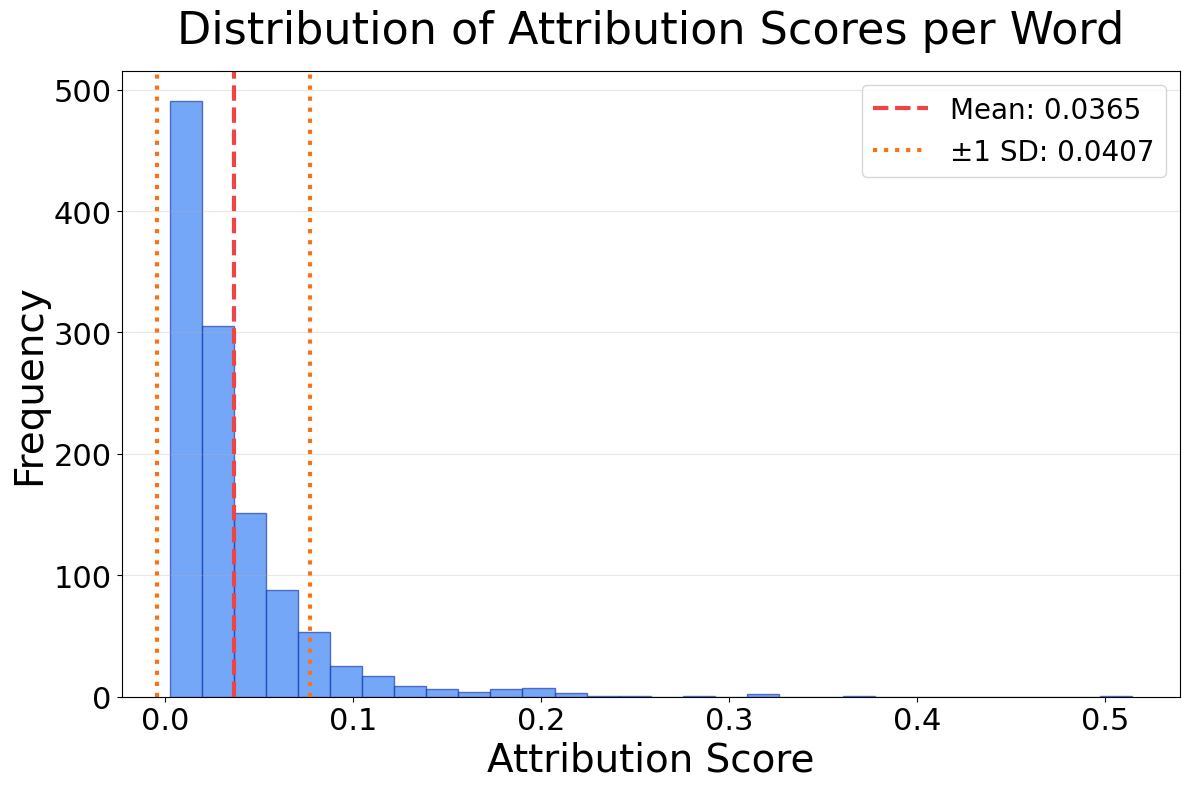

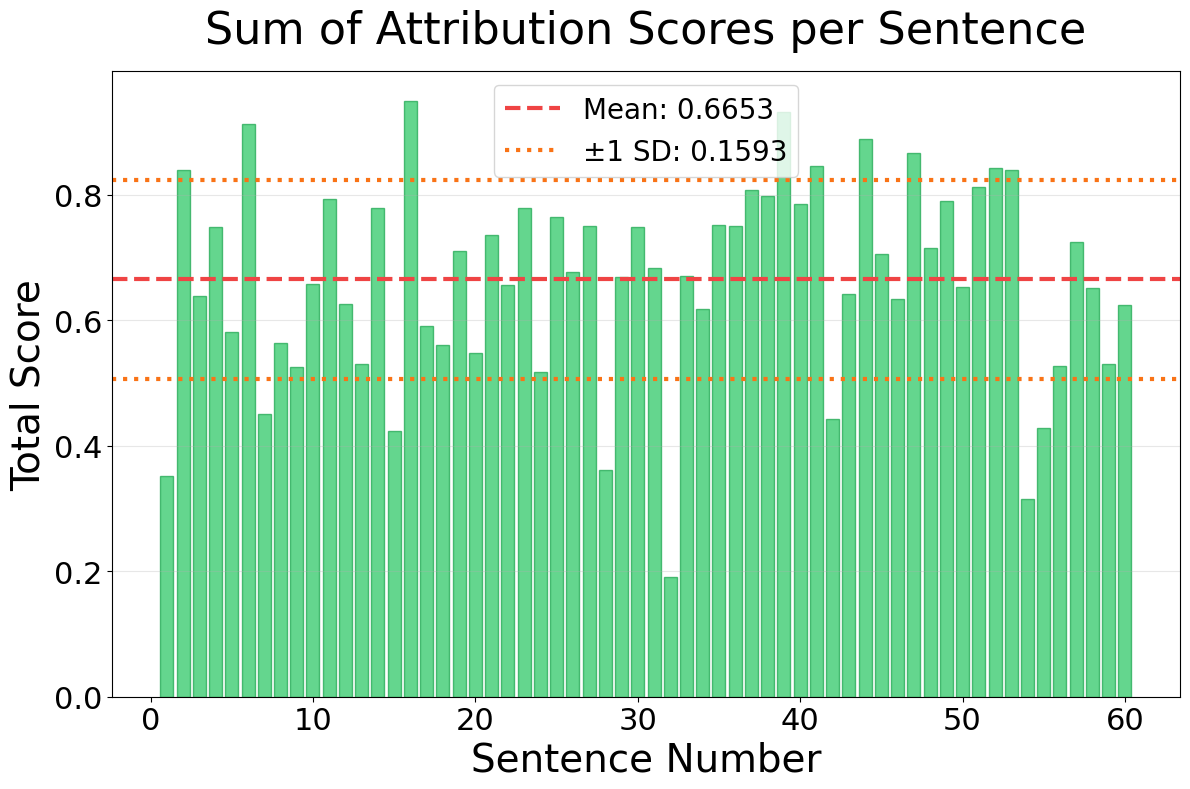


=== DETAILED STATISTICS ===
Individual Word Scores:
  Mean: 0.036461
  Std Dev: 0.040703
  Min: 0.002258
  Max: 0.514148
  Range: 0.511890

Sentence Totals:
  Mean: 0.665342
  Std Dev: 0.159310
  Min: 0.190833
  Max: 0.950509
  Range: 0.759676


In [ ]:
# Create visualizations
import matplotlib.pyplot as plt

if all_scores_per_word and all_sums_per_sentence:

    # Plot 1: Distribution of individual word scores
    plt.figure(figsize=(12, 8))
    plt.hist(all_scores_per_word, bins=30, alpha=0.7, color='#3b82f6', edgecolor='#1e40af')
    plt.axvline(average_score_per_word, color='#ef4444', linestyle='--', linewidth=3,
                label=f'Mean: {average_score_per_word:.4f}')
    # Add standard deviation lines
    plt.axvline(average_score_per_word + std_score_per_word, color='#f97316', linestyle=':', linewidth=3,
                label=f'±1 SD: {std_score_per_word:.4f}')
    plt.axvline(average_score_per_word - std_score_per_word, color='#f97316', linestyle=':', linewidth=3)
    plt.title('Distribution of Attribution Scores per Word', fontsize=32, fontweight='medium', pad=20)
    plt.xlabel('Attribution Score', fontsize=28)
    plt.ylabel('Frequency', fontsize=28)
    plt.tick_params(axis='both', which='major', labelsize=22)
    plt.legend(fontsize=20)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


    # Plot 2: Sum scores per sentence
    plt.figure(figsize=(12, 8))
    sentence_numbers = list(range(1, len(all_sums_per_sentence) + 1))
    bars = plt.bar(sentence_numbers, all_sums_per_sentence, alpha=0.7, color='#22c55e', edgecolor='#16a34a')
    plt.axhline(average_sum_per_sentence, color='#ef4444', linestyle='--', linewidth=3,
                label=f'Mean: {average_sum_per_sentence:.4f}')
    # Add standard deviation lines
    plt.axhline(average_sum_per_sentence + std_sum_per_sentence, color='#f97316', linestyle=':', linewidth=3,
                label=f'±1 SD: {std_sum_per_sentence:.4f}')
    plt.axhline(average_sum_per_sentence - std_sum_per_sentence, color='#f97316', linestyle=':', linewidth=3)
    plt.title('Sum of Attribution Scores per Sentence', fontsize=32, fontweight='medium', pad=20)
    plt.xlabel('Sentence Number', fontsize=28)
    plt.ylabel('Total Score', fontsize=28)
    plt.tick_params(axis='both', which='major', labelsize=22)
    plt.legend(fontsize=20)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print additional statistics
    print(f"\n=== DETAILED STATISTICS ===")
    print(f"Individual Word Scores:")
    print(f"  Mean: {average_score_per_word:.6f}")
    print(f"  Std Dev: {std_score_per_word:.6f}")
    print(f"  Min: {min(all_scores_per_word):.6f}")
    print(f"  Max: {max(all_scores_per_word):.6f}")
    print(f"  Range: {max(all_scores_per_word) - min(all_scores_per_word):.6f}")

    print(f"\nSentence Totals:")
    print(f"  Mean: {average_sum_per_sentence:.6f}")
    print(f"  Std Dev: {std_sum_per_sentence:.6f}")
    print(f"  Min: {min(all_sums_per_sentence):.6f}")
    print(f"  Max: {max(all_sums_per_sentence):.6f}")
    print(f"  Range: {max(all_sums_per_sentence) - min(all_sums_per_sentence):.6f}")

## EXTRA 2: Write function that prints all source words + attribution scores and then, using the Excel file of annotations, mark all source words that have also been annotated.

In [ ]:

import pandas as pd

def mark_source_words_with_annotations(out, sentence_index, target_words, annotations):
    """
    Prints the top merged source word attributions for the first target token containing '→',
    after normalizing source attributions for that target token so that they sum to 1.
    Subword tokens are merged into whole words before ranking and printing.
    Also prints the indices of the constituent source tokens.
    Removes the specific target word for this sentence based on sentence_index.
    Compares the attribution source words to the annotations. Marks all source words that have also been annotated.
    """
    out_data = out.sequence_attributions[0]
    # Get source tokens and optionally their ids and original index
    source_tokens = [t.token if hasattr(t, 'token') else str(t) for t in out_data.source]
    target_tokens = [t.token if hasattr(t, 'token') else str(t) for t in out_data.target]

    print(f"\n--- SENTENCE {sentence_index + 1} ---")

    print(source_tokens)
    print(target_tokens)

    # Remove end of line character from source tokens
    if "</s>" in source_tokens:
        source_tokens.remove("</s>")

    # Handle alignment window (important for correct attribution indexing)
    attr_pos_start = getattr(out_data, "attr_pos_start", 0)
    attr_pos_end = getattr(out_data, "attr_pos_end", len(target_tokens))
    aligned_target_tokens = target_tokens[attr_pos_start:attr_pos_end]  # Only tokens with attributions

    # Prepare attribution matrix (handle possible 3D tensor)
    saliency_heatmap = out_data.source_attributions
    if hasattr(saliency_heatmap, "shape") and len(saliency_heatmap.shape) == 3:
        saliency_heatmap = saliency_heatmap.sum(dim=2)

    contrast_scores = out_data.step_scores["contrast_prob_diff"]

    # Find first target token containing "→" in the aligned window
    target_word_index = next((i for i, token in enumerate(aligned_target_tokens) if "→" in token), None)
    if target_word_index is None:
        print("No target token containing '→' found.")
        return

    tgt_token = aligned_target_tokens[target_word_index]
    contrast_val = float(contrast_scores[target_word_index])

    # Collect and normalize attribution scores for this target token (column in matrix)
    raw_scores = [
        float(saliency_heatmap[i][target_word_index].item() if hasattr(saliency_heatmap[i][target_word_index], "item") else saliency_heatmap[i][target_word_index])
        for i in range(len(source_tokens))
    ]
    score_sum = sum(raw_scores)
    normalized_scores = [s / score_sum if score_sum != 0 else 0.0 for s in raw_scores]

    # Merge subwords into words and sum their attribution scores
    merged_words = []
    current_word = ""
    current_score = 0.0
    current_indices = []

    for idx, (token, score) in enumerate(zip(source_tokens, normalized_scores)):
        if token.startswith("▁") or token in [".", "</s>"]:  # Start of a new word or special
            if current_word:
                merged_words.append((current_word, current_score, current_indices))
            # Start new word
            current_word = token.lstrip("▁")
            current_score = score
            current_indices = [idx]
        else:
            current_word += token
            current_score += score
            current_indices.append(idx)
    # Add last word
    if current_word:
        merged_words.append((current_word, current_score, current_indices))

    # Get the specific target word for this sentence
    current_target_word = target_words.get(sentence_index, "").lower()
    print(f"Target word for sentence {sentence_index + 1}: '{current_target_word}'")

    # Create a new list excluding the specific target word for this sentence
    filtered_words = []

    # Extract individual words from compound target words
    all_target_words = set()
    if current_target_word:
        all_target_words.add(current_target_word)  # Add the full compound
        # Add individual words from compounds
        for word_part in current_target_word.split():
            all_target_words.add(word_part)

    print(f"All target words to remove (including compound parts): {all_target_words}")

    for word, score, indices in merged_words:
        word_stripped = word.strip(".,:\"'—.-?![]()")
        word_lower = word_stripped.lower()

        # Check if the word itself is in target_words (including compound parts)
        if word_lower in all_target_words:
            print(f"Removing '{word_stripped}' - found in target_words")
            continue

        # Check if any individual word from a multi-word phrase is in target_words
        word_parts = word_lower.split()
        if any(part in all_target_words for part in word_parts):
            print(f"Removing '{word_stripped}' - contains part in target_words")
            continue

        # If word doesn't match any target words, keep it
        if word_stripped != "":
            filtered_words.append((word_stripped, score, indices))

    merged_words = filtered_words

    # Sort merged words by total attribution score, descending
    merged_words.sort(key=lambda x: x[1], reverse=True)

    print(f"\nFirst target word containing '→' (index {target_word_index + attr_pos_start}): '{tgt_token}'")
    print(f"Contrastive prob diff: {contrast_val:.6f}")

    ## Now compare the attribution source words to the annotations ##
    stopwords = ["", "a", "an", "the", "this", "that", "these", "those"]

    merged_words = [(word, score, indices) for word, score, indices in merged_words
                if word.lower() not in stopwords]

    # Get the current sentence sheet name (e.g., "Sent_1" for sentence_index=0)
    current_sheet_name = f"Sent_{sentence_index + 1}"


    # Check if the current sheet exists in annotations
    if current_sheet_name not in annotations:
        print(f"Warning: Sheet '{current_sheet_name}' not found in annotations")
        # Print all words without annotation marking
        print("All merged source words and their normalized attributions (original order):")
        for word, score, indices in merged_words:
            print(f"Source word '{word}' (source token idx {indices}): normalized attribution score = {score:.6f}")
        print("")
        return

    # Get annotated words for the current sentence only
    annot_df = annotations[current_sheet_name]
    raw_annot_words = set(annot_df['Source_word'].dropna())

    # Split compound words and create expanded annotation set
    annot_words = set()
    for word in raw_annot_words:
        if word not in stopwords:
            # Add the original word
            annot_words.add(word)
            # Split compound words and add individual parts
            word_parts = word.split()
            if len(word_parts) > 1:  # Only if it's actually a compound
                for part in word_parts:
                    if part not in stopwords:
                        annot_words.add(part)

    # Convert back to list for compatibility
    annot_words = list(annot_words)

    # Prepare data for DataFrame with annotation status
    df_data = []

    print("\nAll merged source words and their normalised attributions:")
    for word, score, indices in merged_words:
        is_annotated = word in annot_words
        matched_sheet = current_sheet_name if is_annotated else None

        if is_annotated:
            print(f"Source word '\033[31m{word}\033[0m': normalised attribution score = {score:.6f}")
        else:
            print(f"Source word '{word}': normalised attribution score = {score:.6f}")

        # Add to DataFrame data
        df_data.append({
            'Source_word': word,
            'Score': score,
            'Indices': str(indices),
            'Is_Annotated': is_annotated,
            'Matched_Sheet': matched_sheet,
            'Annotation_Status': 'Annotated' if is_annotated else 'Not Annotated'
        })

    print("")

Run the function and make sure you've also uploaded the Excel annotations file at this point, as we'll be calling it below.

In [ ]:
# Your target words dictionary
target_words = {0: 'flight attendant', 1: 'musician', 2: 'opponent', 3: 'socialite', 4: 'therapist', 5: 'coordinator', 6: 'lover', 7: 'mechanic', 8: 'dancer', 9: 'therapist', 10: 'visitor', 11: 'colleague', 12: 'companion', 13: 'author',
                14: 'clerk', 15: 'student', 16: 'accountant', 17: 'designer', 18: 'baker', 19: 'lover', 20: 'writer', 21: 'winner', 22: 'consumer', 23: 'poet', 24: 'author', 25: 'writer', 26: 'designer', 27: 'bookkeeper', 28: 'clerk',
                29: 'author', 30: 'counselor', 31: 'dancer', 32: 'friend', 33: 'guard', 34: 'officer', 35: 'winner', 36: 'user', 37: 'supporter', 38: 'judge', 39: 'fighter', 40: 'dealer', 41: 'soldier', 42: 'officer', 43: 'player',
                44: 'manager', 45: 'contractor', 46: 'captain', 47: 'farmer', 48: 'maestro', 49: 'construction worker', 50: 'boss', 51: 'driver', 52: 'idiot', 53: 'cook', 54: 'filmmaker', 55: 'admirer', 56: 'follower', 57: 'salesperson',
                58: 'buddy', 59: 'winner'}

#annotations = pd.read_excel('All_annotations_duplicates_removed_majority_min_two_agree.xlsx', sheet_name=None)
annotations = pd.read_excel('Annotations_all_majority.xlsx', sheet_name=None)

# Updated main loop
for i in range(60):  # Iterate through 60 sentences
    en = EN_source[i]
    orig = Opus_MT_ES[i]
    cont = OPUS_MT_ES_contrastive[i]

    # Gets original tokens
    orig_tokens = list(enumerate(attribution_model.encode(orig, as_targets=True).input_tokens[0]))

    out = attribution_model.attribute(
        en,
        orig,
        contrast_targets=cont,
        attribute_target=True,
        attributed_fn="contrast_prob_diff",
        step_scores=["contrast_prob_diff"],
        contrast_targets_alignments=[(i,i) for i in range(len(orig_tokens))],
        show_progress=False                                                       ### Can be commented out if you want the information. Not needed to print though.
    )

    # Pass the sentence index and target_words dictionary to the function
    mark_source_words_with_annotations(out, i, target_words, annotations)

/usr/local/lib/python3.12/dist-packages/inseq/utils/contrast_utils.py:148: UserWarning: Contrastive inputs do not match original inputs when using a contrastive attributed function.
By default we force the original inputs to be used (i.e. only the contrastive predicted target is different).
This is a requirement for gradient-based attribution method, as contrastive inputs don't participate in gradient computation.
For attribution methods with less stringent requirements, set --contrast_force_inputs to True to use the contrastive inputs for attribution instead.
  warnings.warn(



--- SENTENCE 1 ---
['▁What', '▁you', '▁should', '▁never', '▁do', '▁on', '▁a', '▁plane', ':', '▁Flight', '▁attendant', '▁reveals', '▁airline', '▁secrets', '.', '</s>']
['<pad>', '▁Was', '▁man', '▁im', '▁Flugzeug', '▁nie', '▁tun', '▁sollte', ':', '▁Flug', 'begleit', 'erin → er', '▁verrät', '▁Flug', 'geheimnis', 'se', '.', '</s>']
Target word for sentence 1: 'flight attendant'
All target words to remove (including compound parts): {'attendant', 'flight', 'flight attendant'}
Removing 'Flight' - found in target_words
Removing 'attendant' - found in target_words

First target word containing '→' (index 11): 'erin → er'
Contrastive prob diff: 0.726632

All merged source words and their normalised attributions:
Source word 'reveals': normalised attribution score = 0.068456
Source word 'secrets': normalised attribution score = 0.067118
Source word 'plane': normalised attribution score = 0.064997
Source word 'airline': normalised attribution score = 0.056887
Source word 'never': normalised attr

## EXTRA 3: How I found to use "aggregate" function to get the actual source attribution ranks (although the actual values are still slightly different)

In [ ]:
import inspect
print(inspect.getsource(out.show))

    def show(
        self,
        min_val: Optional[int] = None,
        max_val: Optional[int] = None,
        display: bool = True,
        return_html: Optional[bool] = False,
        aggregator: Union[AggregatorPipeline, type[Aggregator]] = None,
        do_aggregation: bool = True,
        **kwargs,
    ) -> Optional[str]:
        """Visualize the sequence attributions.

        Args:
            min_val (int, optional): Minimum value for color scale.
            max_val (int, optional): Maximum value for color scale.
            display (bool, optional): If True, display the attribution visualization.
            return_html (bool, optional): If True, return the attribution visualization as HTML.
            aggregator (:obj:`AggregatorPipeline` or :obj:`Type[Aggregator]`, optional): Aggregator
                or pipeline to use. If not provided, the default aggregator for every sequence attribution
                is used.
            do_aggregation (:obj:`bool`, *optional*, d

In [ ]:
print(type(out.sequence_attributions[0]))
print(dir(out.sequence_attributions[0]))

<class 'inseq.data.attribution.GranularFeatureAttributionSequenceOutput'>
['__abstractmethods__', '__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__json_decode__', '__json_encode__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__post_init__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_aggregator', '_detach', '_dict_aggregate_fn', '_eq', '_getitem', '_numpy', '_select_active', '_slice_batch', '_to', '_torch', 'aggregate', 'attr_pos_end', 'attr_pos_start', 'clone', 'clone_empty', 'detach', 'from_step_attributions', 'get_remove_pad_fn', 'get_scores_dicts', 'maximum', 'minimum', 'numpy', 'select_active', 'sequence_scores', 'show', 'slice_bat

In [ ]:
import inspect
print(inspect.getsource(out.sequence_attributions[0].show))

    def show(
        self,
        min_val: Optional[int] = None,
        max_val: Optional[int] = None,
        display: bool = True,
        return_html: Optional[bool] = False,
        aggregator: Union[AggregatorPipeline, type[Aggregator]] = None,
        do_aggregation: bool = True,
        **kwargs,
    ) -> Optional[str]:
        """Visualize the attributions.

        Args:
            min_val (:obj:`int`, *optional*, defaults to None):
                Minimum value in the color range of the visualization. If None, the minimum value of the attributions
                across all visualized examples is used.
            max_val (:obj:`int`, *optional*, defaults to None):
                Maximum value in the color range of the visualization. If None, the maximum value of the attributions
                across all visualized examples is used.
            display (:obj:`bool`, *optional*, defaults to True):
                Whether to display the visualization. Can be set to False

In [ ]:
from inseq import show_attributions

# Suppose 'out' is your FeatureAttributionOutput object from attribution_model.attribute()
aggregated = out.aggregate()  # or out.aggregate(aggregator) if you want to specify

# Then call show_attributions with these parameters (replace min_val etc. as needed)
show_attributions(aggregated, min_val=None, max_val=None, display=True, return_html=False)

,▁Ein,▁Hotel,angestellte,▁wurde → r,▁auf → ▁wurde,▁Video → ▁auf,▁erwischt → ▁Video,▁und → ▁erwischt,▁nannte → ▁und,▁einen → ▁nannte,▁schwarzen → ▁einen,▁Kunden → ▁schwarzen,▁einen → ▁Kunden,▁Affen → ▁einen,. → ▁Affen,</s> → .,</s>
▁A,0.0,0.0,0.0,0.011,0.02,0.019,0.008,0.01,0.01,0.011,0.001,0.008,0.002,0.001,0.002,0.0,0.0
▁hotel,0.0,0.0,0.0,0.019,0.024,0.026,0.021,0.018,0.018,0.015,0.002,0.013,0.01,0.002,0.004,0.001,0.0
▁clerk,0.0,0.0,0.0,0.145,0.086,0.069,0.052,0.057,0.052,0.038,0.006,0.032,0.019,0.003,0.009,0.002,0.0
▁was,0.0,0.0,0.0,0.011,0.042,0.027,0.012,0.016,0.014,0.015,0.002,0.007,0.002,0.001,0.002,0.001,0.0
▁caught,0.0,0.0,0.0,0.035,0.187,0.108,0.059,0.195,0.076,0.047,0.004,0.02,0.007,0.002,0.005,0.002,0.0
▁on,0.0,0.0,0.0,0.012,0.049,0.092,0.041,0.042,0.052,0.022,0.002,0.011,0.005,0.002,0.003,0.001,0.0
▁video,0.0,0.0,0.0,0.017,0.06,0.142,0.173,0.07,0.081,0.034,0.004,0.022,0.009,0.003,0.005,0.002,0.0
▁calling,0.0,0.0,0.0,0.018,0.054,0.129,0.068,0.067,0.086,0.125,0.008,0.024,0.016,0.007,0.009,0.005,0.0
▁a,0.0,0.0,0.0,0.006,0.017,0.028,0.02,0.016,0.019,0.026,0.005,0.012,0.007,0.002,0.005,0.001,0.0
▁black,0.0,0.0,0.0,0.007,0.015,0.024,0.016,0.015,0.016,0.024,0.004,0.072,0.016,0.002,0.006,0.001,0.0


In [ ]:
agg = out.aggregate()
print(agg)

FeatureAttributionOutput({
    sequence_attributions: list with 1 elements of type GranularFeatureAttributionSequenceOutput: [
        GranularFeatureAttributionSequenceOutput({
            source: list with 15 elements of type TokenWithId: [
                '▁A', '▁hotel', '▁clerk', '▁was', '▁caught', '▁on', '▁video', '▁calling', '▁a', '▁black', '▁customer', '▁a', '▁monkey', '.', '</s>'
            ],
            target: list with 18 elements of type TokenWithId: [
                '<pad>', '▁Ein', '▁Hotel', 'angestellte', '▁wurde → r', '▁auf → ▁wurde', '▁Video → ▁auf', '▁erwischt → ▁Video', '▁und → ▁erwischt', '▁nannte → ▁und', '▁einen → ▁nannte', '▁schwarzen → ▁einen', '▁Kunden → ▁schwarzen', '▁einen → ▁Kunden', '▁Affen → ▁einen', '. → ▁Affen', '</s> → .', '</s>'
            ],
            source_attributions: torch.float32 tensor of shape [15, 17] on cpu: [
                [  0.00,  0.00,  0.00,  0.01,  0.02,  0.02,  0.01,  0.01,  0.01,  0.01,  0.00,  0.01,  0.00,  0.00,  0.00,  0.0